# 01 — Análise exploratória do EuroSAT

O **EuroSAT** é um dataset de classificação de uso/cobertura do solo baseado em imagens do satélite **Sentinel-2**. São **27.000 imagens** de 64×64 px, rotuladas em **10 classes**, cada uma com **13 bandas espectrais** (do visível ao infravermelho de ondas curtas — SWIR).

Objetivo deste notebook: entender o dataset visual e numericamente antes de construir o pipeline. Em especial, queremos *ver* a informação que as bandas não-visíveis carregam — o cerne da hipótese do projeto.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

from src import config
from src import visualization as viz

ds = tfds.load(config.DATASET_NAME, split='train', shuffle_files=False)
print('Classes:', config.CLASS_NAMES)
print('Bandas :', config.BAND_NAMES)

I0000 00:00:1780156343.825261    4432 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Bandas : ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B10', 'B11', 'B12']


I0000 00:00:1780156346.987354    4432 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:06:00.0, compute capability: 8.6


## 1. Distribuição por classe

Verificamos quão balanceado é o dataset — desbalanceamento forte exigiria cuidado extra (pesos de classe, F1 macro etc.).

I0000 00:00:1780156347.616037    4555 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Total de imagens: 27000


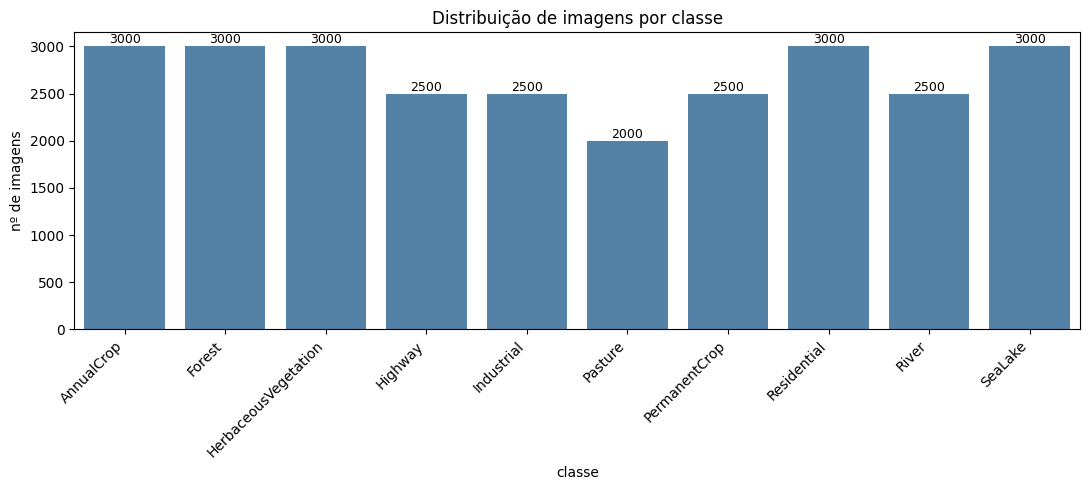

In [2]:
labels = np.array([int(ex[config.LABEL_KEY]) for ex in ds])
print('Total de imagens:', len(labels))
viz.plot_class_distribution(labels)
plt.show()

## 2. Uma amostra de cada classe

Grade com uma imagem (composição RGB visível) por classe, para ter intuição do que o modelo precisa distinguir.

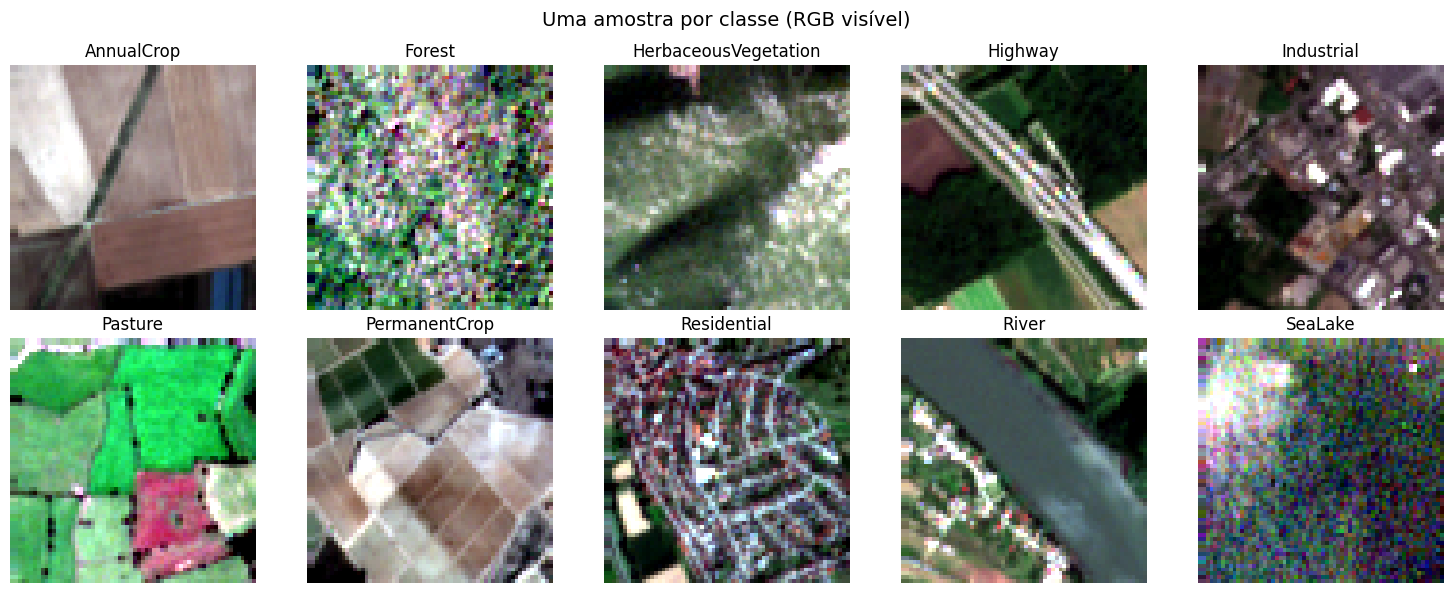

In [3]:
# Coleta a primeira imagem de cada classe.
samples = {}
for ex in ds:
    lbl = int(ex[config.LABEL_KEY])
    if lbl not in samples:
        samples[lbl] = ex[config.IMAGE_KEY].numpy()
    if len(samples) == config.NUM_CLASSES:
        break

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for lbl, ax in zip(sorted(samples), axes.flat):
    ax.imshow(viz.rgb_composite(samples[lbl]))
    ax.set_title(config.CLASS_NAMES[lbl])
    ax.axis('off')
fig.suptitle('Uma amostra por classe (RGB visível)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. As 13 bandas de uma mesma cena

Aqui fica visível o porquê do projeto: cada banda captura uma faixa diferente do espectro. Bandas de infravermelho (B8, B8A) e SWIR (B11, B12) realçam vegetação e umidade de forma que o olho humano (RGB) não enxerga.

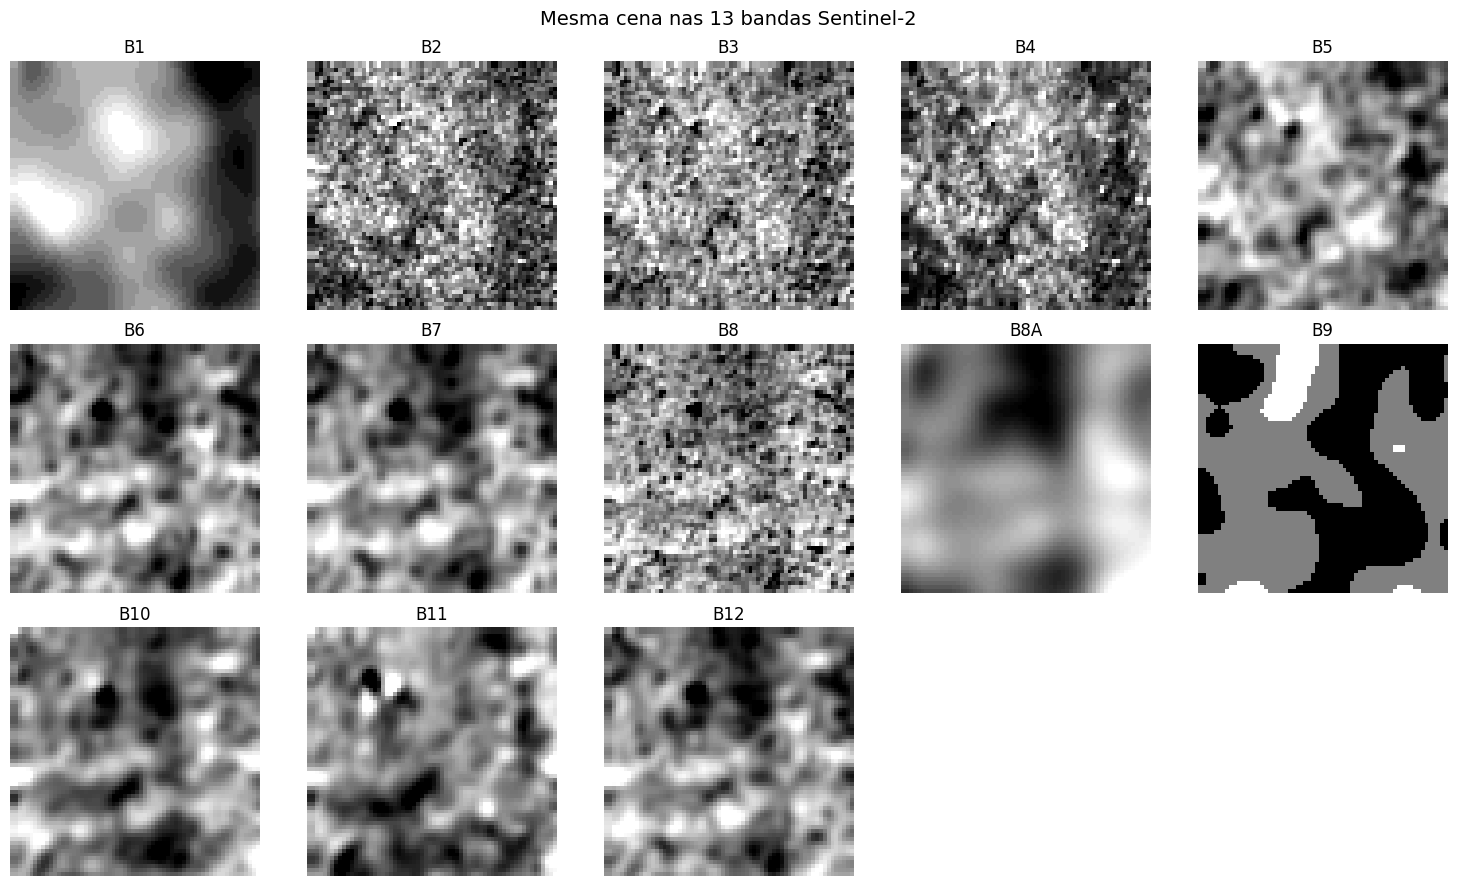

In [4]:
forest_img = samples[config.CLASS_NAMES.index('Forest')]
viz.plot_band_comparison(forest_img)
plt.show()

## 4. NDVI — o índice de vegetação

O **NDVI** = (B8 − B4) / (B8 + B4) usa a banda NIR (B8) e a vermelha (B4). Vegetação saudável reflete muito NIR e pouco vermelho → NDVI alto. Comparamos uma cena de floresta com uma de área residencial: a separação é gritante, e depende **inteiramente** de uma banda não-visível.

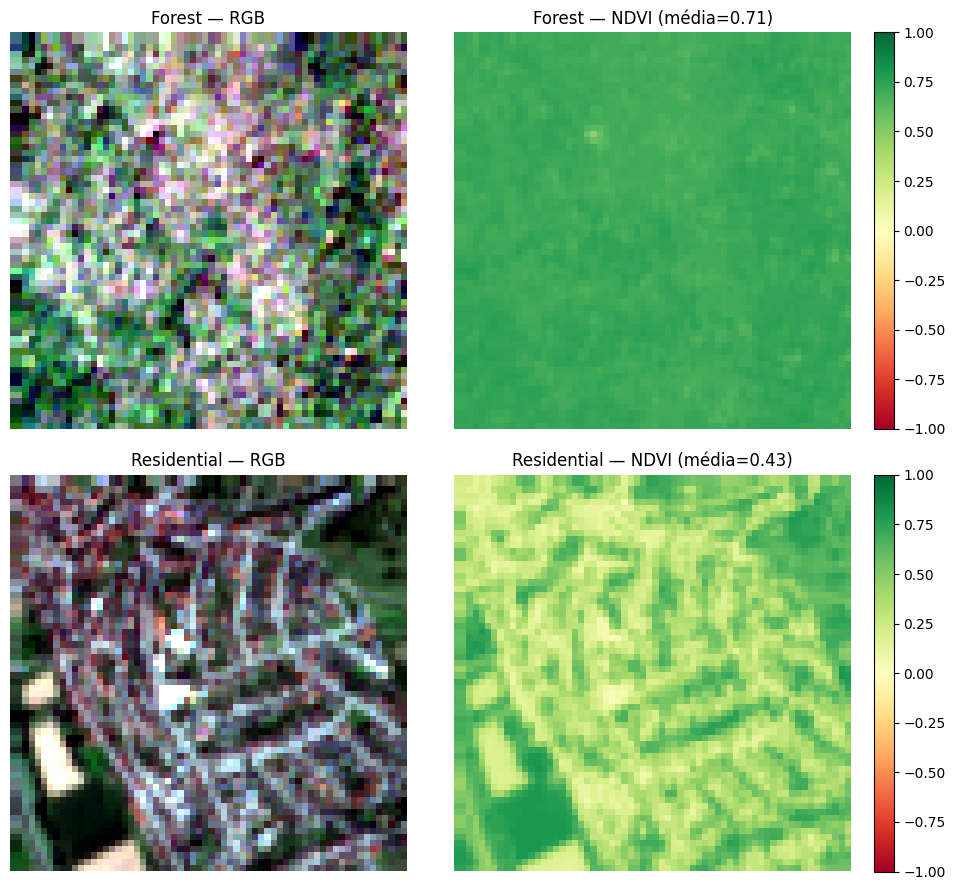

In [5]:
forest = samples[config.CLASS_NAMES.index('Forest')]
resid = samples[config.CLASS_NAMES.index('Residential')]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for row, (img, name) in enumerate([(forest, 'Forest'), (resid, 'Residential')]):
    ndvi = viz.compute_ndvi(img)
    axes[row, 0].imshow(viz.rgb_composite(img)); axes[row, 0].set_title(f'{name} — RGB'); axes[row, 0].axis('off')
    im = axes[row, 1].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[row, 1].set_title(f'{name} — NDVI (média={ndvi.mean():.2f})'); axes[row, 1].axis('off')
    fig.colorbar(im, ax=axes[row, 1], fraction=0.046)
plt.tight_layout()
plt.show()

## 5. Histograma de valores por banda

As bandas do EuroSAT all-bands são valores de reflectância **brutos** (não normalizados), com faixas bem diferentes entre si. Isso confirma a necessidade de normalização **por banda** (z-score) no pipeline — feita no notebook 02.

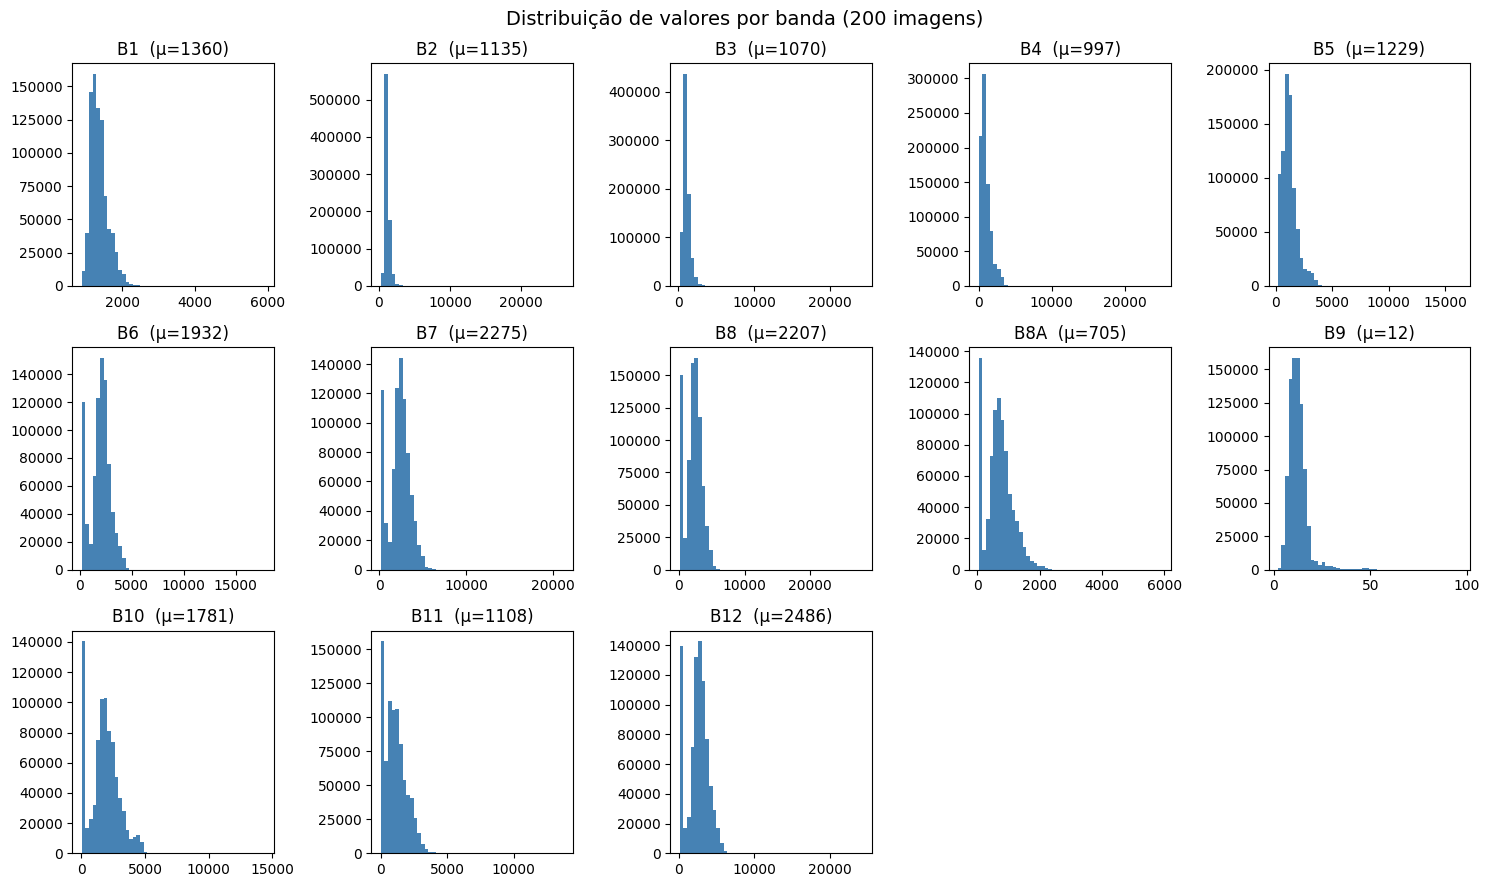

In [6]:
# Amostra de pixels de várias imagens para os histogramas.
stack = np.stack([ex[config.IMAGE_KEY].numpy() for ex in ds.take(200)])  # (200,64,64,13)
pixels = stack.reshape(-1, config.NUM_BANDS)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat):
    if i < config.NUM_BANDS:
        ax.hist(pixels[:, i], bins=50, color='steelblue')
        ax.set_title(f'{config.BAND_NAMES[i]}  (μ={pixels[:,i].mean():.0f})')
    else:
        ax.axis('off')
fig.suptitle('Distribuição de valores por banda (200 imagens)', fontsize=14)
plt.tight_layout()
plt.show()

## Conclusões da EDA

- Dataset **balanceado** (~2.000–3.000 imagens por classe).
- As bandas não-visíveis carregam informação clara (NDVI separa vegetação de construção quase perfeitamente).
- Valores brutos com escalas muito diferentes entre bandas → **normalização por banda é obrigatória**.

**Próximo passo:** `02_data_pipeline.ipynb`.